In [1]:
# Before traing
# Automatically detect and crop each sticker
import cv2
import numpy as np
from PIL import Image
import os

def auto_crop_stickers(image_path, output_dir, min_area=5000):
    """
    min_area: Minimum area filtering (to filter out noise)
    """

    img = cv2.imread(image_path)
    original = img.copy()
    height, width = img.shape[:2]

    # 1. Convert to greyscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Gaussian blur noise reduction
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. Binarisation
    _, thresh = cv2.threshold(blurred, 240, 255, cv2.THRESH_BINARY_INV)

    # 4. Remove minor noise
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)

    # 5. Find contours
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    os.makedirs(output_dir, exist_ok=True)

    # 6. Process each contour
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)

        if area < min_area:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        # Add margin
        padding = 10
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(width - x, w + 2*padding)
        h = min(height - y, h + 2*padding)

        # Crop
        cropped = original[y:y+h, x:x+w]

        cv2.imwrite(f"{output_dir}/sticker_{i:03d}.png", cropped)

        cv2.rectangle(original, (x, y), (x+w, y+h), (0, 255, 0), 2)

    cv2.imwrite(f"{output_dir}/detected_boxes.jpg", original)
    print(f"Find {i+1} stickers")


# auto_crop_stickers("VCG211486349220.jpg", "cropped20/")
# auto_crop_stickers("VCG211486349416.jpg", "cropped16/")
# auto_crop_stickers("VCG211486349504.jpg", "cropped04/")
# auto_crop_stickers("VCG211486382989.jpg", "cropped89/")
# auto_crop_stickers("VCG211486349446.jpg", "cropped46/")

# !zip -r cropped04.zip cropped04
# !zip -r cropped16.zip cropped16
# !zip -r cropped20.zip cropped20
# !zip -r cropped89.zip cropped89
# !zip -r cropped46.zip cropped46

In [2]:
# @title 1. Install dependencies
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install diffusers accelerate transformers peft pillow tqdm
!pip install xformers

print("✅")

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.6 MB/s eta 0:00:00
✅


In [3]:
# @title 2. Connect Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/sticker_project"
data_path = os.path.join(project_path, "data/my_sticker_style")
lora_path = os.path.join(project_path, "lora_weights")

os.makedirs(data_path, exist_ok=True)
os.makedirs(lora_path, exist_ok=True)

print(f"✅ Google Drive")
print(f"📁 Data path: {data_path}")
print(f"📁 LoRA path: {lora_path}")

Mounted at /content/drive
✅ Google Drive
📁 Data path: /content/drive/MyDrive/sticker_project/data/my_sticker_style
📁 LoRA path: /content/drive/MyDrive/sticker_project/lora_weights


In [4]:
# @title 3. Start training(about 20-25 min)
!python /content/drive/MyDrive/sticker_project/train_lora_colab.py --train

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.

=== Step 1: Data Augmentation ===
Found 27 original images
Generating 4 augmented versions per image....
Data Augmentation: 100% 27/27 [00:28<00:00,  1.06s/it]
✅ Augmentation complete! Total 135 images

=== Step 2: Load Pretrained model ===
model_index.json: 100% 541/541 [00:00<00:00, 2.50MB/s]
Fetching 13 files: 100% 13/13 [01:00<00:00,  4.69s/it]
Download complete: : 4.27GB [01:01, 62.8MB/s]              
Loading pipeline components...:   0% 0/6 [00:00<?, ?it/s]
Download complete: : 4.27GB [01:01, 69.6MB/s]
Loading weights: 100% 196/196 [00:00<00:00, 902.07it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwa

Latest validation samples:

--- step_1200_cat.png ---


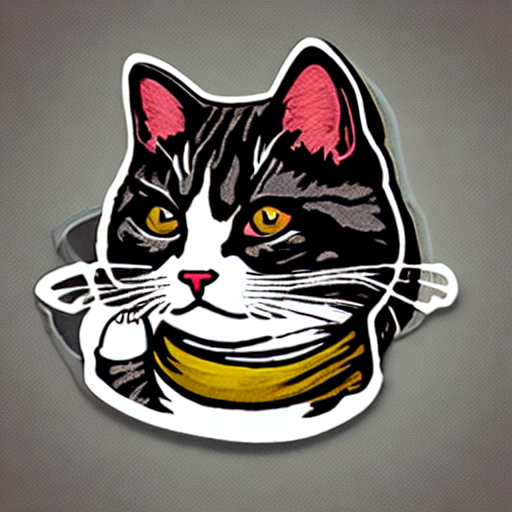


--- step_1200_dog.png ---


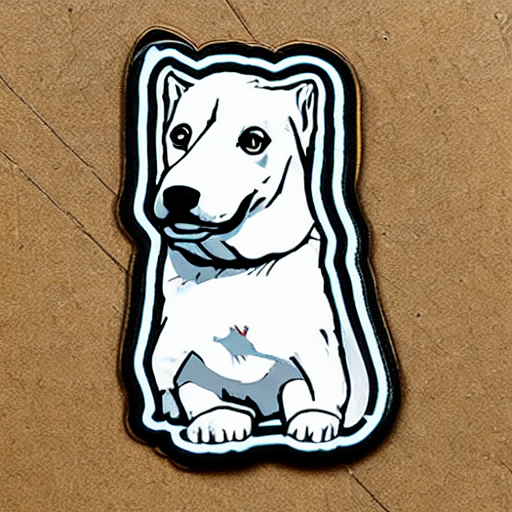


--- step_1200_rabbit.png ---


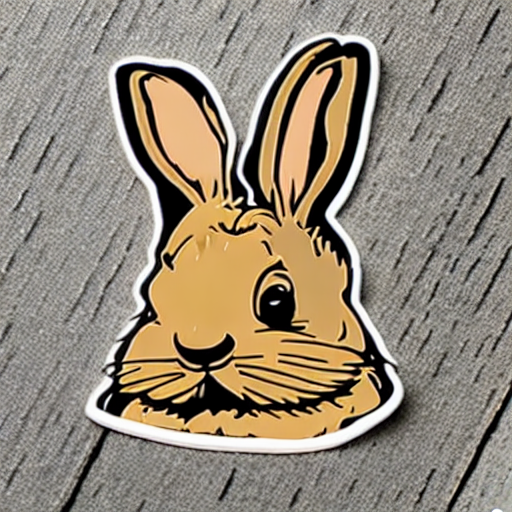

In [5]:
# @title 4. View verification samples
from IPython.display import Image, display
import os

validation_dir = "/content/validation_samples"
if os.path.exists(validation_dir):
    print("Latest validation samples:")
    files = sorted(os.listdir(validation_dir))[3:6]  # last 3 validation
    for f in files:
        print(f"\n--- {f} ---")
        display(Image(os.path.join(validation_dir, f)))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Load LoRA: /content/drive/MyDrive/sticker_project/lora_weights/lora_final
Loading pipeline components...:   0% 0/6 [00:00<?, ?it/s]
Loading weights:   0% 0/196 [00:00<?, ?it/s]
Loading weights:   1% 1/196 [00:00<00:00, 7231.56it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   1% 1/196 [00:00<00:00, 2968.37it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   1% 2/196 [00:00<00:00, 2204.05it/s, Materializing param=text_model.embeddings.token_embedding.weight]   
Loading weights:   1% 2/196 [00:00<00:00, 1877.07it/s, Materializing param=text_model.embeddings.token_embedding.weight]
Loading weights:   2% 3/196 [00:

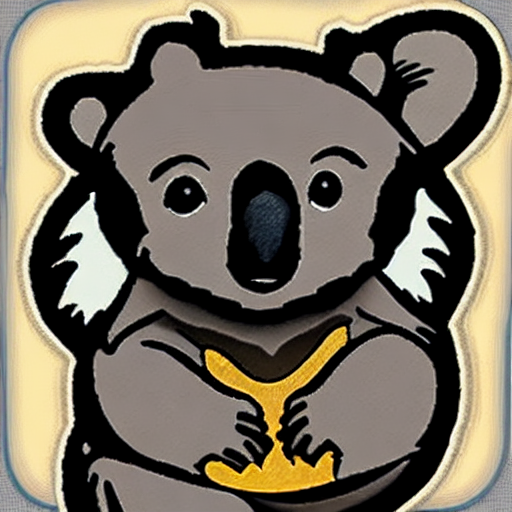


--- fox_sticker_1.png ---


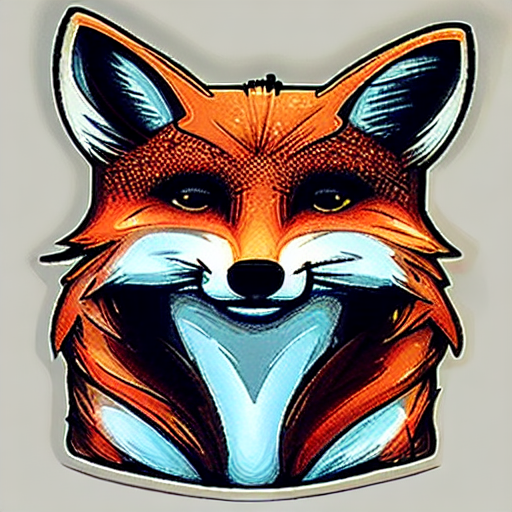


--- fish_sticker_1.png ---


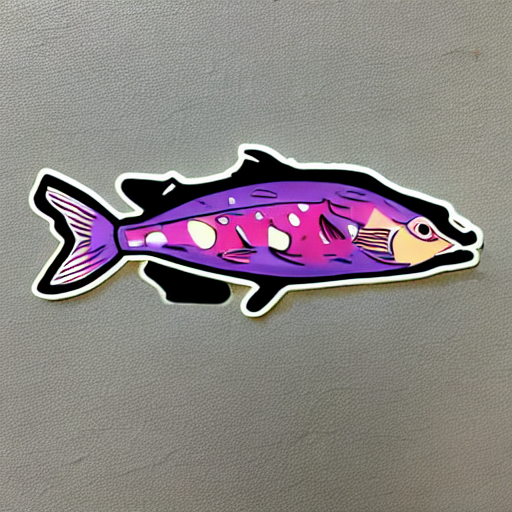


--- dog_sticker_0.png ---


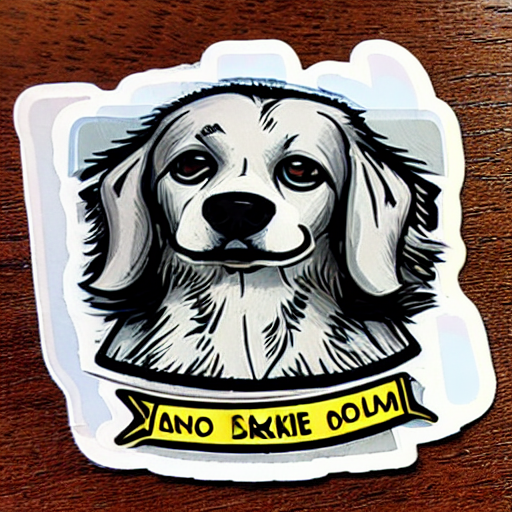


--- deer_sticker_1.png ---


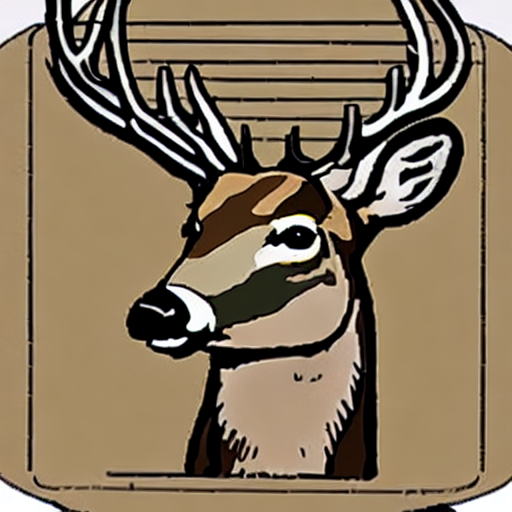


--- deer_sticker_0.png ---


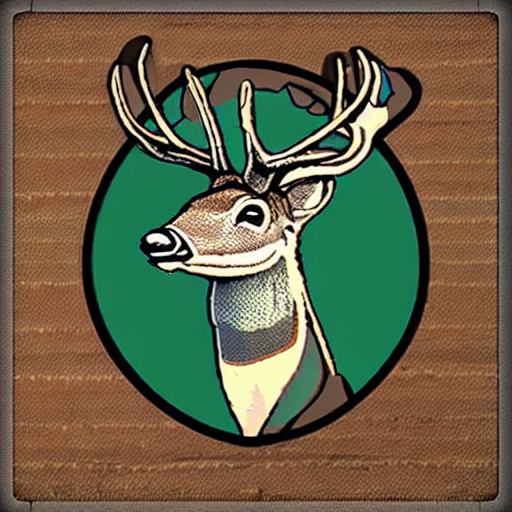

In [6]:
# @title 5. Test generated stickers
!python /content/drive/MyDrive/sticker_project/train_lora_colab.py --test

from IPython.display import Image, display
import os

test_dir = "/content/test_output"
if os.path.exists(test_dir):
    print("Generated stickers:")
    for f in os.listdir(test_dir)[:6]:
        if f.endswith('.png'):
            print(f"\n--- {f} ---")
            display(Image(os.path.join(test_dir, f)))

In [7]:
# @title 6. Download the pre-trained LoRA and the generated stickers
from google.colab import files
import os

!cd /content/drive/MyDrive/sticker_project && zip -r lora_weights.zip lora_weights
!cp /content/drive/MyDrive/sticker_project/lora_weights.zip /content/

print("Download LoRA weights:")
files.download('/content/lora_weights.zip')

print("\nDownload test images:")
if os.path.exists('/content/test_output.zip'):
    files.download('/content/test_output.zip')

updating: lora_weights/ (stored 0%)
updating: lora_weights/lora_step_200/ (stored 0%)
updating: lora_weights/lora_step_200/README.md (deflated 65%)
updating: lora_weights/lora_step_200/adapter_model.safetensors (deflated 7%)
updating: lora_weights/lora_step_200/adapter_config.json (deflated 58%)
updating: lora_weights/lora_step_400/ (stored 0%)
updating: lora_weights/lora_step_400/README.md (deflated 65%)
updating: lora_weights/lora_step_400/adapter_model.safetensors (deflated 7%)
updating: lora_weights/lora_step_400/adapter_config.json (deflated 58%)
updating: lora_weights/lora_step_600/ (stored 0%)
updating: lora_weights/lora_step_600/README.md (deflated 65%)
updating: lora_weights/lora_step_600/adapter_model.safetensors (deflated 7%)
updating: lora_weights/lora_step_600/adapter_config.json (deflated 58%)
updating: lora_weights/lora_step_800/ (stored 0%)
updating: lora_weights/lora_step_800/README.md (deflated 65%)
updating: lora_weights/lora_step_800/adapter_model.safetensors (defla

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download test images:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>